# Mutual Fund Performance Analytics


This notebook performs quantitative performance analysis of mutual funds using historical NAV data.

The analysis includes:

- Daily Returns
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

plt.style.use("ggplot")

In [2]:
# Load datasets

nav = pd.read_csv("data/processed/02_nav_history_cleaned.csv")

performance = pd.read_csv(
    "data/processed/07_scheme_performance_cleaned.csv"
)

fund_master = pd.read_csv(
    "data/processed/01_fund_master_cleaned.csv"
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
# Convert date column

nav["date"] = pd.to_datetime(nav["date"])

# Sort values

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


## 1. Daily Return Calculation

Daily return represents the percentage change in NAV compared to the previous trading day.

Formula:

Daily Return = (Today's NAV / Previous Day NAV) − 1

## 1. Daily Return Analysis

Daily return measures the percentage change in a mutual fund's Net Asset Value (NAV) from one trading day to the next.

**Formula:**

Daily Return = (Current NAV / Previous NAV) − 1

This analysis helps understand the short-term performance and volatility of each mutual fund scheme.

In [4]:
# Calculate daily returns for each scheme

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

# Display first few rows
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [5]:
# Count missing values

nav["daily_return"].isnull().sum()

np.int64(40)

In [6]:
# Summary statistics

nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

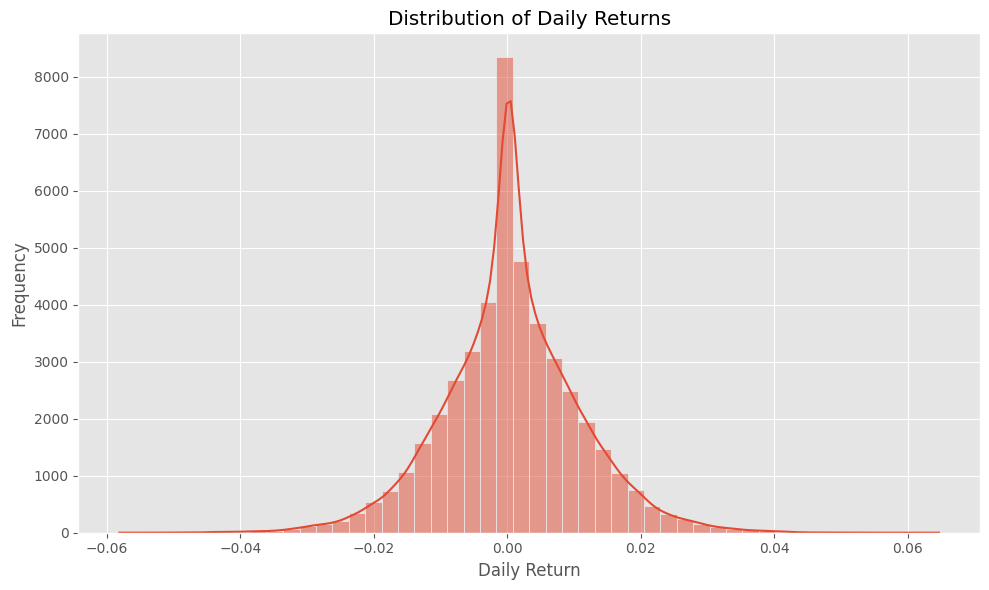

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

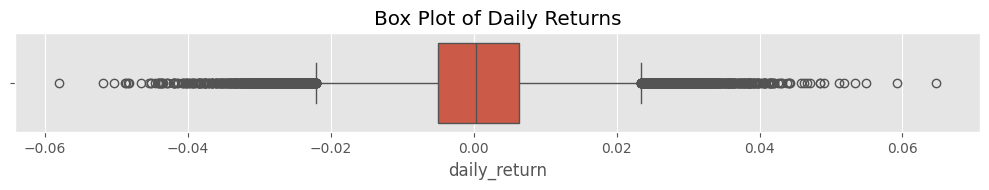

In [8]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=nav["daily_return"].dropna()
)

plt.title("Box Plot of Daily Returns")

plt.tight_layout()

plt.show()

In [9]:
nav.to_csv(
    "data/processed/nav_daily_returns.csv",
    index=False
)

print("Daily returns calculated and saved successfully.")

Daily returns calculated and saved successfully.


### Insight

The distribution of daily returns is centered around zero with relatively small fluctuations, indicating that most daily NAV changes are within a reasonable range. A few extreme values represent periods of higher market volatility.

## 2. Compound Annual Growth Rate (CAGR)

CAGR measures the average annual growth rate of a mutual fund over a specified period.

Formula:

CAGR = (Ending NAV / Beginning NAV)^(1 / Years) - 1

This metric provides a standardized way to compare the long-term performance of different mutual fund schemes.

In [10]:
# Function to calculate CAGR

def calculate_cagr(start_nav, end_nav, years):
    if start_nav > 0 and end_nav > 0:
        return (end_nav / start_nav) ** (1 / years) - 1
    else:
        return np.nan

In [11]:
cagr_data = []

for scheme in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == scheme].sort_values("date")

    if len(fund) < 2:
        continue

    start_nav = fund.iloc[0]["nav"]
    end_nav = fund.iloc[-1]["nav"]

    scheme_name = performance.loc[
        performance["amfi_code"] == scheme,
        "scheme_name"
    ].values

    scheme_name = scheme_name[0] if len(scheme_name) > 0 else "Unknown"

    cagr_data.append({
        "amfi_code": scheme,
        "scheme_name": scheme_name,
        "CAGR_1Y": calculate_cagr(start_nav, end_nav, 1),
        "CAGR_3Y": calculate_cagr(start_nav, end_nav, 3),
        "CAGR_5Y": calculate_cagr(start_nav, end_nav, 5)
    })

cagr_df = pd.DataFrame(cagr_data)

cagr_df.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.121336,0.038912,0.023168
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.211552,0.066058,0.039127
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,2.185142,0.471328,0.260741
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.534562,0.363435,0.204427
4,101207,ABSL Small Cap Fund - Regular - Growth,0.399496,0.118555,0.069533


In [12]:
cagr_df["CAGR_1Y"] = cagr_df["CAGR_1Y"] * 100
cagr_df["CAGR_3Y"] = cagr_df["CAGR_3Y"] * 100
cagr_df["CAGR_5Y"] = cagr_df["CAGR_5Y"] * 100

cagr_df.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,12.133575,3.891151,2.316843
1,100025,HDFC Short Term Debt Fund - Regular - Growth,21.155227,6.605772,3.912653
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,218.514228,47.132838,26.074068
3,101206,ABSL Frontline Equity Fund - Regular - Growth,153.456216,36.343461,20.442730
4,101207,ABSL Small Cap Fund - Regular - Growth,39.949603,11.855469,6.953336


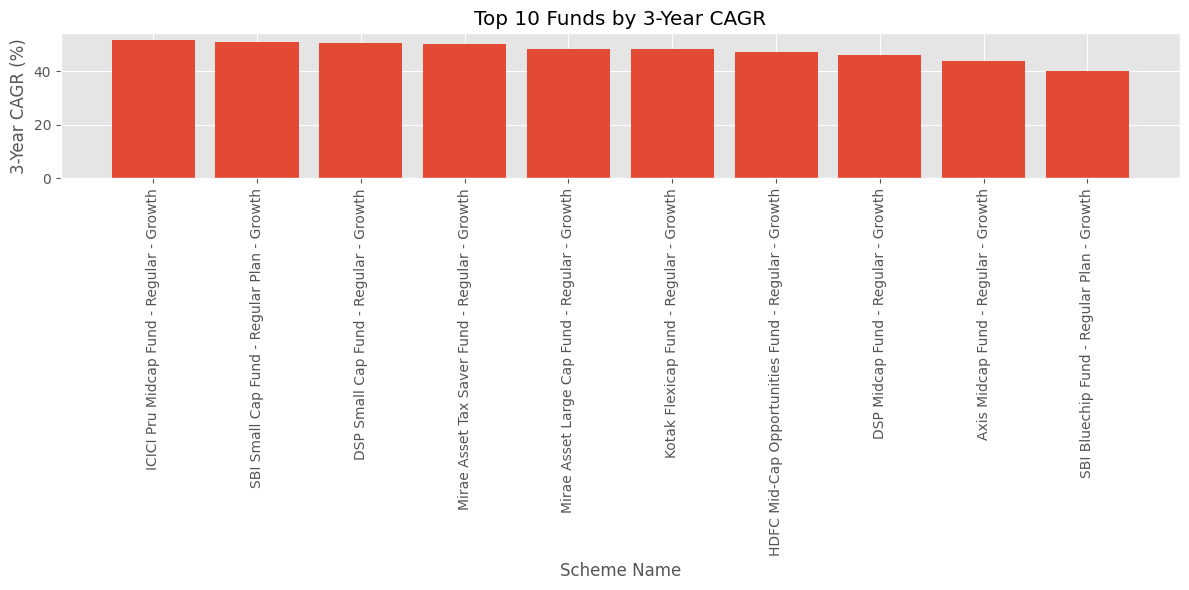

In [13]:
top_cagr = cagr_df.sort_values(
    by="CAGR_3Y",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_cagr["scheme_name"],
    top_cagr["CAGR_3Y"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by 3-Year CAGR")
plt.xlabel("Scheme Name")
plt.ylabel("3-Year CAGR (%)")

plt.tight_layout()

plt.show()

In [14]:
cagr_df.to_csv(
    "reports/cagr_comparison.csv",
    index=False
)

print("CAGR comparison table saved successfully.")

CAGR comparison table saved successfully.


### Insight

The CAGR comparison highlights the long-term annualized growth of each mutual fund scheme. Funds with higher 3-year and 5-year CAGR values have demonstrated stronger and more consistent historical performance.

## 3. Sharpe Ratio Analysis

The Sharpe Ratio measures the risk-adjusted return of a mutual fund.

Formula:

Sharpe Ratio = ((Average Return − Risk Free Rate) / Standard Deviation) × √252

Assumptions:

- Risk-free rate = 6.5% annually
- Trading days = 252 per year

A higher Sharpe Ratio indicates better return for each unit of risk.

In [15]:
# Annual Risk-Free Rate

risk_free_rate = 0.065

# Convert annual rate to daily

daily_rf = risk_free_rate / 252

In [16]:
sharpe_list = []

for scheme in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == scheme]

    returns = fund["daily_return"].dropna()

    if len(returns) == 0:
        continue

    avg_return = returns.mean()

    std_return = returns.std()

    sharpe = ((avg_return - daily_rf) / std_return) * np.sqrt(252)

    scheme_name = performance.loc[
        performance["amfi_code"] == scheme,
        "scheme_name"
    ].values

    scheme_name = scheme_name[0] if len(scheme_name) > 0 else "Unknown"

    sharpe_list.append({
        "amfi_code": scheme,
        "scheme_name": scheme_name,
        "Sharpe_Ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_list)

sharpe_df.head()

,amfi_code,scheme_name,Sharpe_Ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.201517
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.567095
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027213
4,101207,ABSL Small Cap Fund - Regular - Growth,0.162661


In [17]:
sharpe_df = sharpe_df.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

sharpe_df.reset_index(drop=True, inplace=True)

sharpe_df.head(10)

,amfi_code,scheme_name,Sharpe_Ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448291
1,120843,Kotak Flexicap Fund - Regular - Growth,1.306744
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930
3,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208267
4,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180101
5,149323,DSP Midcap Fund - Regular - Growth,1.132122
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699
7,118632,Nippon India Large Cap Fund - Regular - Growth,1.081659
8,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027213
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.026524


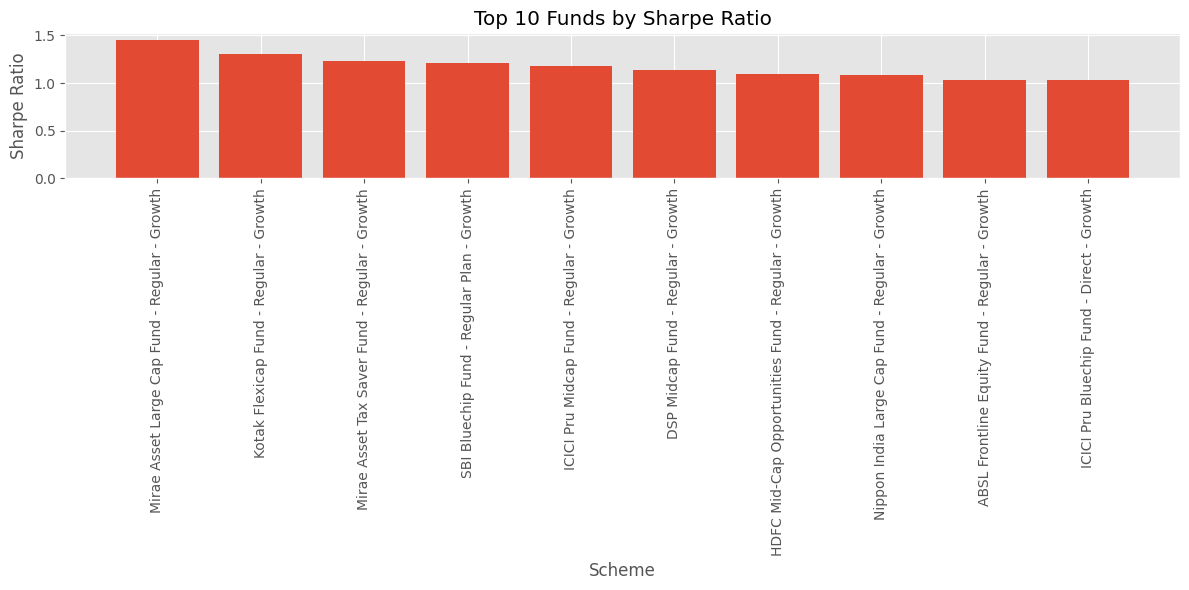

In [18]:
plt.figure(figsize=(12,6))

top10 = sharpe_df.head(10)

plt.bar(
    top10["scheme_name"],
    top10["Sharpe_Ratio"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.xlabel("Scheme")

plt.ylabel("Sharpe Ratio")

plt.tight_layout()

plt.show()

In [19]:
sharpe_df.to_csv(
    "reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio file saved successfully.")

Sharpe Ratio file saved successfully.


### Insight

Funds with higher Sharpe Ratios delivered better risk-adjusted returns. These schemes generated comparatively higher returns while taking relatively lower investment risk.

## 4. Sortino Ratio Analysis

The Sortino Ratio measures the risk-adjusted return of a mutual fund by considering only downside risk (negative returns).

Unlike the Sharpe Ratio, it ignores positive price fluctuations and focuses only on harmful volatility.

Formula:

Sortino Ratio = ((Average Return − Risk Free Rate) / Downside Standard Deviation) × √252

Assumptions:
- Risk-free rate = 6.5% annually
- Trading days = 252 per year

In [20]:
# List to store Sortino Ratio results
sortino_list = []

for scheme in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == scheme]

    returns = fund["daily_return"].dropna()

    if len(returns) == 0:
        continue

    # Average return
    avg_return = returns.mean()

    # Negative returns only
    downside_returns = returns[returns < 0]

    # Downside deviation
    downside_std = downside_returns.std()

    # Avoid division by zero
    if pd.isna(downside_std) or downside_std == 0:
        sortino = np.nan
    else:
        sortino = ((avg_return - daily_rf) / downside_std) * np.sqrt(252)

    # Scheme name
    scheme_name = performance.loc[
        performance["amfi_code"] == scheme,
        "scheme_name"
    ].values

    scheme_name = scheme_name[0] if len(scheme_name) > 0 else "Unknown"

    sortino_list.append({
        "amfi_code": scheme,
        "scheme_name": scheme_name,
        "Sortino_Ratio": sortino
    })

# Create DataFrame
sortino_df = pd.DataFrame(sortino_list)

sortino_df.head()

,amfi_code,scheme_name,Sortino_Ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.351047
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.941821
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.799563
4,101207,ABSL Small Cap Fund - Regular - Growth,0.276644


In [21]:
# Rank funds based on Sortino Ratio
sortino_df = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

sortino_df.reset_index(drop=True, inplace=True)

sortino_df.head(10)

,amfi_code,scheme_name,Sortino_Ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,2.385644
1,120843,Kotak Flexicap Fund - Regular - Growth,2.364320
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914
3,119551,SBI Bluechip Fund - Regular Plan - Growth,2.140267
4,120505,ICICI Pru Midcap Fund - Regular - Growth,2.029353
5,149323,DSP Midcap Fund - Regular - Growth,1.875101
6,118632,Nippon India Large Cap Fund - Regular - Growth,1.850133
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134
8,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.805294
9,101206,ABSL Frontline Equity Fund - Regular - Growth,1.799563


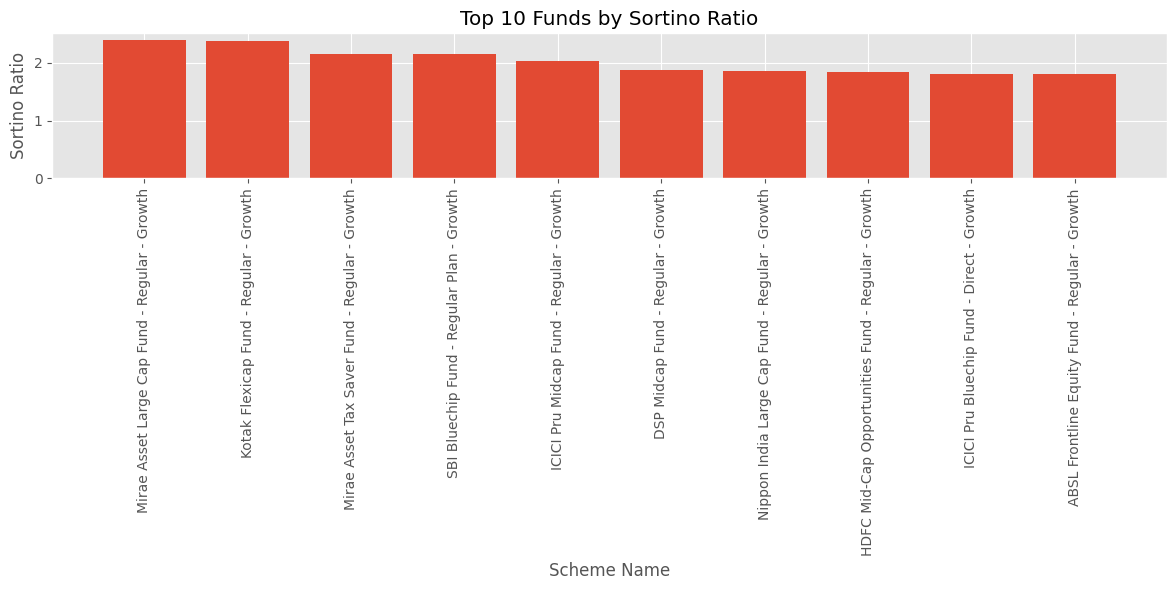

In [22]:
plt.figure(figsize=(12,6))

top10 = sortino_df.head(10)

plt.bar(
    top10["scheme_name"],
    top10["Sortino_Ratio"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sortino Ratio")

plt.xlabel("Scheme Name")
plt.ylabel("Sortino Ratio")

plt.tight_layout()

plt.show()

In [23]:
sortino_df.to_csv(
    "reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio saved successfully.")

Sortino Ratio saved successfully.


### Insight

The Sortino Ratio evaluates fund performance by considering only downside risk. Funds with higher Sortino Ratios generated better returns while experiencing lower downside volatility.

## 5. Alpha and Beta Analysis

Alpha measures the excess return generated by a mutual fund compared to its benchmark.

Beta measures the sensitivity of a mutual fund's returns relative to the benchmark.

This analysis uses the Nifty 100 Index as the benchmark and applies Ordinary Least Squares (OLS) regression using `scipy.stats.linregress()`.

In [24]:
# Load benchmark data

benchmark = pd.read_csv(
    "data/processed/10_benchmark_indices_cleaned.csv"
)

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [25]:
# Convert date column

benchmark["date"] = pd.to_datetime(benchmark["date"])

# Select only Nifty 100

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Sort values

nifty100 = nifty100.sort_values("date")

# Daily returns

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [26]:
alpha_beta_list = []

for scheme in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == scheme
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = regression.slope

    alpha = regression.intercept * 252

    scheme_name = performance.loc[
        performance["amfi_code"] == scheme,
        "scheme_name"
    ].values

    scheme_name = scheme_name[0] if len(scheme_name) > 0 else "Unknown"

    alpha_beta_list.append({
        "amfi_code": scheme,
        "scheme_name": scheme_name,
        "Alpha": alpha,
        "Beta": beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta_list)

alpha_beta_df.head()

,amfi_code,scheme_name,Alpha,Beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086
4,101207,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289


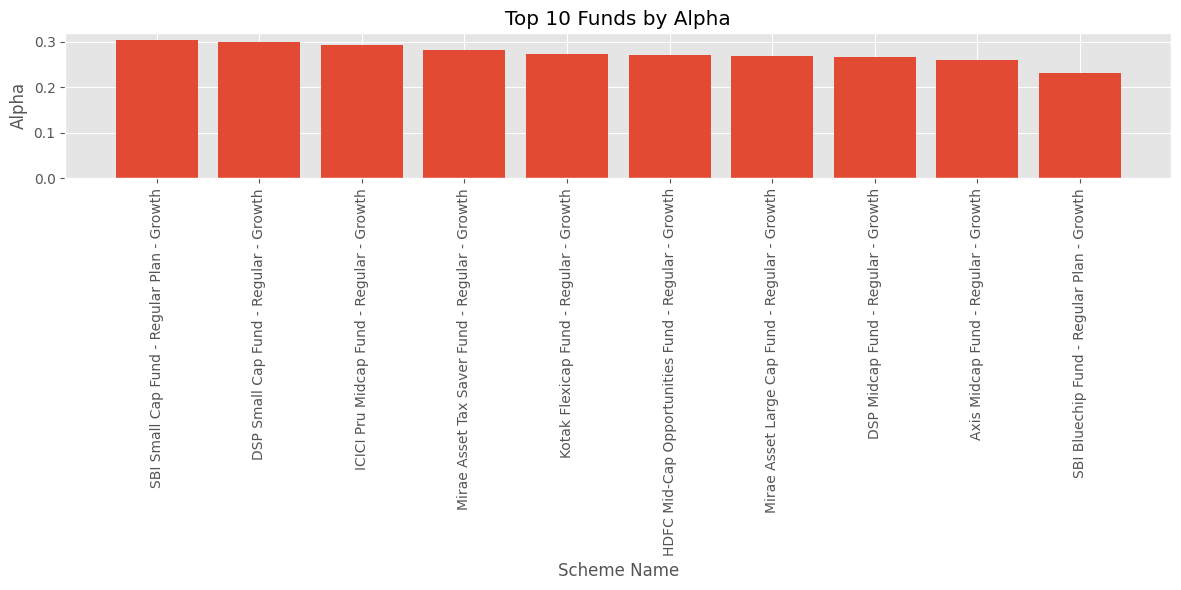

In [27]:
top_alpha = alpha_beta_df.sort_values(
    by="Alpha",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_alpha["scheme_name"],
    top_alpha["Alpha"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Alpha")

plt.xlabel("Scheme Name")

plt.ylabel("Alpha")

plt.tight_layout()

plt.show()

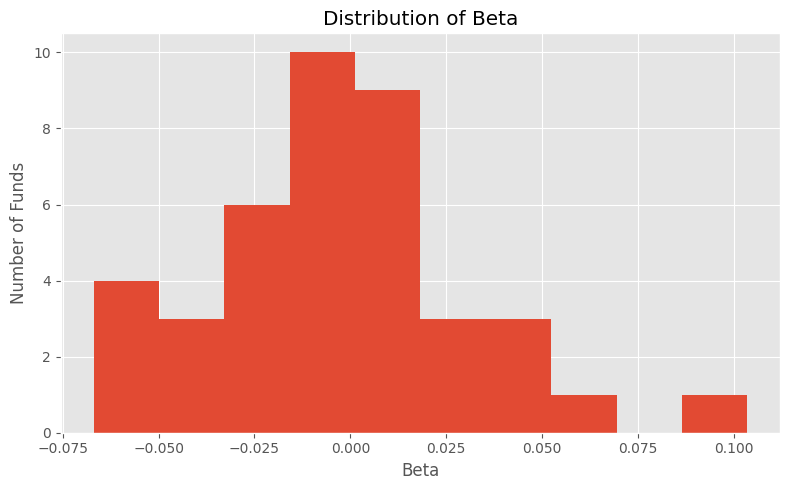

In [28]:
plt.figure(figsize=(8,5))

plt.hist(
    alpha_beta_df["Beta"],
    bins=10
)

plt.title("Distribution of Beta")

plt.xlabel("Beta")

plt.ylabel("Number of Funds")

plt.tight_layout()

plt.show()

In [29]:
alpha_beta_df.to_csv(
    "reports/alpha_beta.csv",
    index=False
)

print("Alpha & Beta analysis completed successfully.")

Alpha & Beta analysis completed successfully.


### Insight

Funds with positive Alpha generated returns above the benchmark after adjusting for market movements. Beta values close to 1 indicate performance similar to the benchmark, while values above 1 suggest higher market sensitivity.

## 6. Maximum Drawdown Analysis

Maximum Drawdown measures the largest decline in a fund's NAV from its previous peak before recovering.

Formula:

Maximum Drawdown = (Current NAV / Running Maximum NAV) − 1

A lower (more negative) drawdown indicates a larger loss from the highest NAV value.

In [30]:
# Create a copy of NAV data
drawdown_data = nav.copy()

# Running maximum NAV for each fund
drawdown_data["running_max"] = (
    drawdown_data.groupby("amfi_code")["nav"]
    .cummax()
)

# Calculate drawdown
drawdown_data["drawdown"] = (
    drawdown_data["nav"] /
    drawdown_data["running_max"]
) - 1

drawdown_data.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [31]:
max_drawdown = (
    drawdown_data.groupby("amfi_code")
    .agg(
        Maximum_Drawdown=("drawdown", "min")
    )
    .reset_index()
)

max_drawdown.head()

,amfi_code,Maximum_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [32]:
max_drawdown = max_drawdown.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

max_drawdown.head()

,amfi_code,Maximum_Drawdown,scheme_name
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth


In [33]:
worst_dates = (
    drawdown_data.loc[
        drawdown_data.groupby("amfi_code")["drawdown"].idxmin(),
        ["amfi_code", "date"]
    ]
)

worst_dates.rename(
    columns={"date": "Worst_Drawdown_Date"},
    inplace=True
)

worst_dates.head()

,amfi_code,Worst_Drawdown_Date
183,100016,2022-09-15
1559,100025,2023-07-28
2393,100033,2022-05-12
3842,101206,2023-07-05
5735,101207,2026-05-11


In [34]:
max_drawdown = max_drawdown.merge(
    worst_dates,
    on="amfi_code",
    how="left"
)

max_drawdown.head()

,amfi_code,Maximum_Drawdown,scheme_name,Worst_Drawdown_Date
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth,2022-09-15
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth,2023-07-28
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,2022-05-12
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth,2023-07-05
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth,2026-05-11


In [35]:
max_drawdown = max_drawdown.sort_values(
    by="Maximum_Drawdown",
    ascending=False
)

max_drawdown.head(10)

,amfi_code,Maximum_Drawdown,scheme_name,Worst_Drawdown_Date
27,120507,-0.000977,ICICI Pru Liquid Fund - Regular - Growth,2025-10-20
31,120844,-0.001163,Kotak Liquid Fund - Regular - Growth,2024-04-30
5,101208,-0.001622,ABSL Liquid Fund - Regular - Growth,2023-09-12
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth,2023-07-28
18,119120,-0.043287,SBI Magnum Gilt Fund - Regular Plan - Growth,2025-04-01
13,118636,-0.083164,Nippon India Gilt Securities Fund - Regular - ...,2024-02-09
6,102885,-0.108599,UTI Nifty 50 Index Fund - Regular - Growth,2022-03-29
34,148567,-0.112657,Mirae Asset Large Cap Fund - Regular - Growth,2023-10-20
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth,2023-07-05
12,118635,-0.116506,Nippon India ETF Nifty 50 BeES,2022-06-09


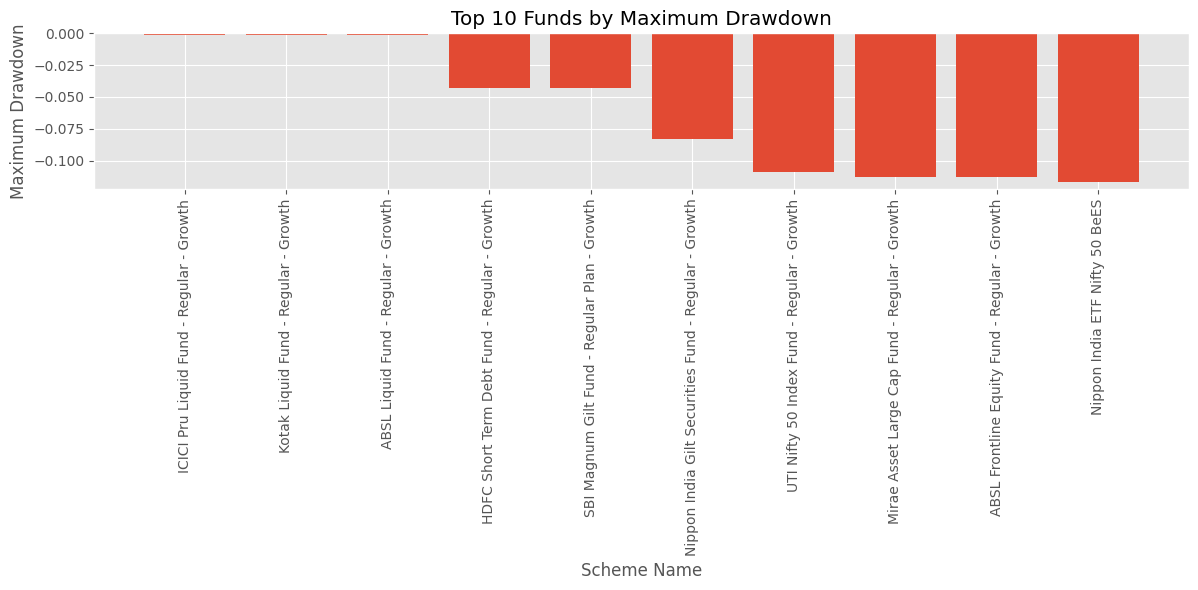

In [36]:
plt.figure(figsize=(12,6))

top10 = max_drawdown.head(10)

plt.bar(
    top10["scheme_name"],
    top10["Maximum_Drawdown"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Maximum Drawdown")

plt.xlabel("Scheme Name")

plt.ylabel("Maximum Drawdown")

plt.tight_layout()

plt.show()

In [37]:
max_drawdown.to_csv(
    "reports/maximum_drawdown.csv",
    index=False
)

print("Maximum Drawdown analysis completed successfully.")

Maximum Drawdown analysis completed successfully.


### Insight

Maximum Drawdown measures the largest decline experienced by each mutual fund from its highest NAV. Funds with smaller drawdowns demonstrate better downside protection during market corrections.

# 7. Fund Scorecard (0–100)

The Fund Scorecard provides an overall performance score for each mutual fund by combining multiple performance indicators.

Scoring Weights:

- 30% : 3-Year Return Rank
- 25% : Sharpe Ratio Rank
- 20% : Alpha Rank
- 15% : Expense Ratio Rank (Lower is Better)
- 10% : Maximum Drawdown Rank (Lower Drawdown is Better)

The final score ranges from 0 to 100, where a higher score indicates better overall performance.

In [38]:
# Merge all performance metrics

scorecard = performance[[
    "amfi_code",
    "scheme_name",
    "return_3yr_pct",
    "expense_ratio_pct"
]].copy()

scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "Alpha"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    max_drawdown[["amfi_code", "Maximum_Drawdown"]],
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287


In [39]:
# Higher return is better
scorecard["Return_Rank"] = scorecard["return_3yr_pct"].rank(
    ascending=False
)

# Higher Sharpe is better
scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(
    ascending=False
)

# Higher Alpha is better
scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(
    ascending=False
)

# Lower expense ratio is better
scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

# Lower drawdown is better
scorecard["Drawdown_Rank"] = scorecard["Maximum_Drawdown"].rank(
    ascending=False
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.150124,26.0,4.0,10.0,30.5,17.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.118035,34.0,12.0,15.0,4.0,11.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060,1.0,14.0,1.0,21.0,36.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-0.525742,2.0,32.0,36.0,5.5,40.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287,38.0,37.0,34.0,9.0,5.0


In [40]:
n = len(scorecard)

scorecard["Return_Score"] = (n - scorecard["Return_Rank"]) / (n - 1) * 100

scorecard["Sharpe_Score"] = (n - scorecard["Sharpe_Rank"]) / (n - 1) * 100

scorecard["Alpha_Score"] = (n - scorecard["Alpha_Rank"]) / (n - 1) * 100

scorecard["Expense_Score"] = (n - scorecard["Expense_Rank"]) / (n - 1) * 100

scorecard["Drawdown_Score"] = (n - scorecard["Drawdown_Rank"]) / (n - 1) * 100

In [41]:
scorecard["Fund_Score"] = (

      scorecard["Return_Score"] * 0.30

    + scorecard["Sharpe_Score"] * 0.25

    + scorecard["Alpha_Score"] * 0.20

    + scorecard["Expense_Score"] * 0.15

    + scorecard["Drawdown_Score"] * 0.10

)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score,Fund_Score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.150124,26.0,4.0,10.0,30.5,17.0,35.897436,92.307692,76.923077,24.358974,58.974359,58.782051
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.118035,34.0,12.0,15.0,4.0,11.0,15.384615,71.794872,64.102564,92.307692,74.358974,56.666667
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060,1.0,14.0,1.0,21.0,36.0,100.000000,66.666667,100.000000,48.717949,10.256410,75.000000
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-0.525742,2.0,32.0,36.0,5.5,40.0,97.435897,20.512821,10.256410,88.461538,0.000000,49.679487
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287,38.0,37.0,34.0,9.0,5.0,5.128205,7.692308,15.384615,79.487179,89.743590,27.435897


In [42]:
scorecard = scorecard.sort_values(
    by="Fund_Score",
    ascending=False
)

scorecard.reset_index(
    drop=True,
    inplace=True
)

scorecard.head(10)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score,Fund_Score
0,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180101,0.292636,-0.181885,8.0,5.0,3.0,15.0,25.0,82.051282,89.743590,94.871795,64.102564,38.461538,79.487179
1,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.306744,0.273305,-0.129740,11.0,2.0,5.0,22.0,13.0,74.358974,97.435897,89.743590,46.153846,69.230769,78.461538
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,-0.162172,10.0,7.0,6.0,17.0,20.0,76.923077,84.615385,87.179487,58.974359,51.282051,75.641026
3,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060,1.0,14.0,1.0,21.0,36.0,100.000000,66.666667,100.000000,48.717949,10.256410,75.000000
4,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.448291,0.269838,-0.112657,17.0,1.0,7.0,23.0,8.0,58.974359,100.000000,84.615385,43.589744,82.051282,74.358974
5,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,0.949796,0.300579,-0.311719,6.0,13.0,2.0,26.5,37.0,87.179487,69.230769,97.435897,34.615385,7.692308,68.910256
6,149323,DSP Midcap Fund - Regular - Growth,17.16,1.61,1.132122,0.265986,-0.172481,9.0,6.0,8.0,38.0,22.0,79.487179,87.179487,82.051282,5.128205,46.153846,67.435897
7,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,0.80,1.026524,0.211948,-0.125883,20.0,10.0,13.0,12.0,12.0,51.282051,76.923077,69.230769,71.794872,71.794872,66.410256
8,119094,Axis Midcap Fund - Regular - Growth,15.18,1.38,0.998231,0.260767,-0.209609,15.0,11.0,9.0,17.0,28.0,64.102564,74.358974,79.487179,58.974359,30.769231,65.641026
9,148569,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,1.60,1.234930,0.282704,-0.163967,23.0,3.0,4.0,36.5,21.0,43.589744,94.871795,92.307692,8.974359,48.717949,61.474359


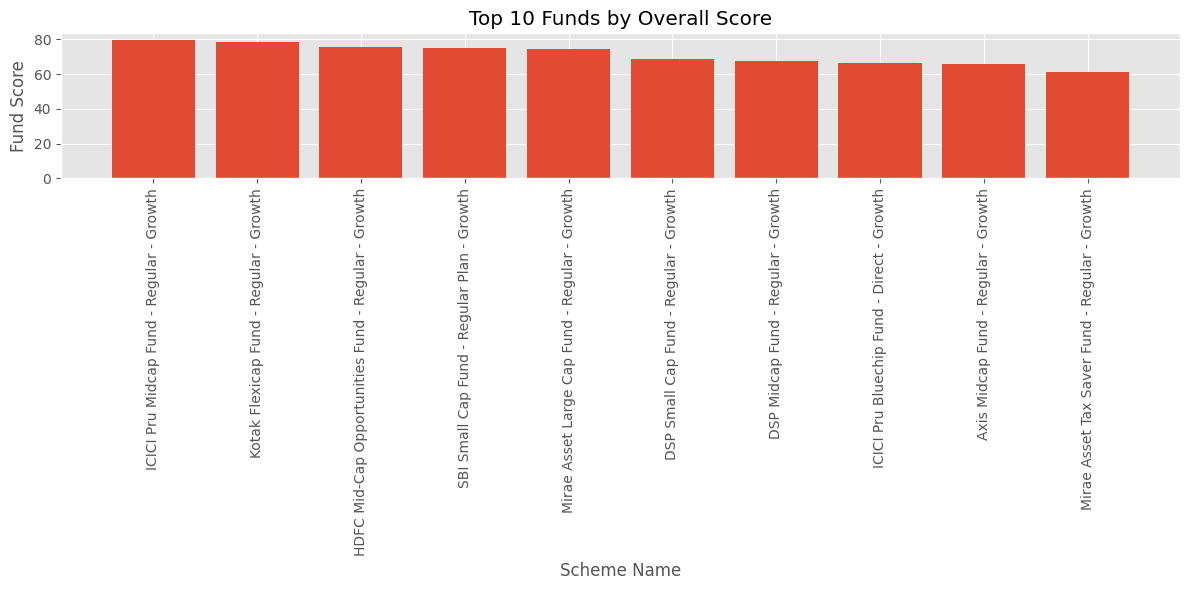

In [43]:
plt.figure(figsize=(12,6))

top10 = scorecard.head(10)

plt.bar(
    top10["scheme_name"],
    top10["Fund_Score"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Overall Score")

plt.xlabel("Scheme Name")

plt.ylabel("Fund Score")

plt.tight_layout()

plt.show()

In [44]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved successfully.")

Fund Scorecard saved successfully.


### Insight

The Fund Scorecard combines return, risk-adjusted performance, alpha generation, expense efficiency, and downside protection into a single performance metric. Funds with higher scores demonstrate stronger overall investment quality.

# 8. Benchmark Comparison

This analysis compares the cumulative performance of the top 5 mutual funds against the Nifty 50 and Nifty 100 benchmark indices.

Tracking Error measures how closely a mutual fund follows its benchmark.

Formula:

Tracking Error = Standard Deviation(Fund Return − Benchmark Return) × √252

In [45]:
# Load benchmark data

benchmark = pd.read_csv(
    "data/processed/10_benchmark_indices_cleaned.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

# Sort values

benchmark = benchmark.sort_values("date")

In [46]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Daily returns

nifty50["return"] = nifty50["close_value"].pct_change()

nifty100["return"] = nifty100["close_value"].pct_change()

In [47]:
top5_codes = scorecard.head(5)["amfi_code"].tolist()

top5_codes

[120505, 120843, 100033, 119598, 148567]

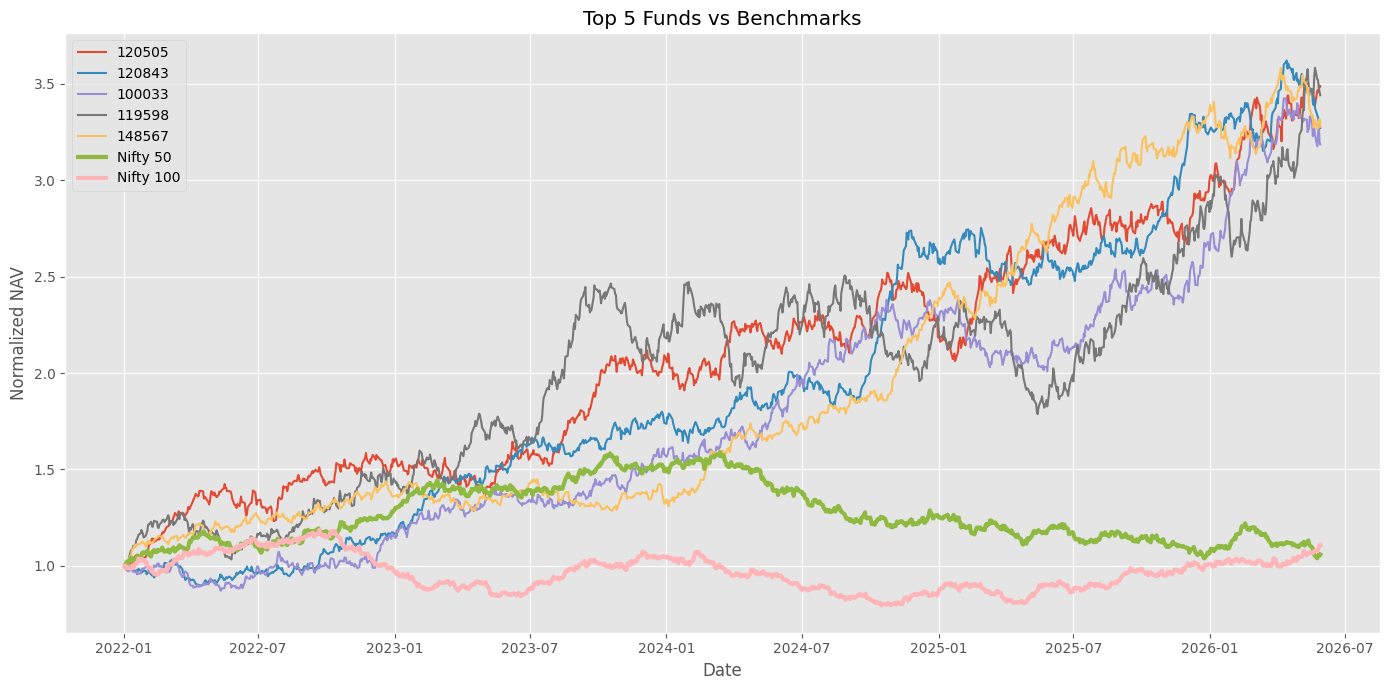

In [48]:
plt.figure(figsize=(14,7))

# Plot Top 5 Funds

for code in top5_codes:

    fund = nav[
        nav["amfi_code"] == code
    ].copy()

    fund = fund.sort_values("date")

    normalized_nav = (
        fund["nav"] /
        fund["nav"].iloc[0]
    )

    plt.plot(
        fund["date"],
        normalized_nav,
        label=str(code)
    )

# Nifty 50

nifty50_norm = (
    nifty50["close_value"] /
    nifty50["close_value"].iloc[0]
)

plt.plot(
    nifty50["date"],
    nifty50_norm,
    linewidth=3,
    label="Nifty 50"
)

# Nifty100

nifty100_norm = (
    nifty100["close_value"] /
    nifty100["close_value"].iloc[0]
)

plt.plot(
    nifty100["date"],
    nifty100_norm,
    linewidth=3,
    label="Nifty 100"
)

plt.title("Top 5 Funds vs Benchmarks")

plt.xlabel("Date")

plt.ylabel("Normalized NAV")

plt.legend()

plt.tight_layout()

plt.savefig(
    "reports/charts/benchmark_comparison.png"
)

plt.show()

In [49]:
tracking_error = []

for code in top5_codes:

    fund = nav[
        nav["amfi_code"] == code
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[["date", "return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    te = (
        (merged["daily_return"] - merged["return"]).std()
        * np.sqrt(252)
    )

    name = performance.loc[
        performance["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    tracking_error.append({
        "amfi_code": code,
        "scheme_name": name,
        "Tracking_Error": te
    })

tracking_error_df = pd.DataFrame(tracking_error)

tracking_error_df

,amfi_code,scheme_name,Tracking_Error
0,120505,ICICI Pru Midcap Fund - Regular - Growth,0.231968
1,120843,Kotak Flexicap Fund - Regular - Growth,0.206425
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.228699
3,119598,SBI Small Cap Fund - Regular Plan - Growth,0.283881
4,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.189664


In [50]:
tracking_error_df.to_csv(
    "reports/tracking_error.csv",
    index=False
)

print("Tracking Error saved successfully.")

Tracking Error saved successfully.


### Insight

The benchmark comparison shows how the top-performing mutual funds performed relative to the Nifty 50 and Nifty 100 indices. Funds with lower tracking error follow the benchmark more closely, while higher tracking error indicates greater deviation and potentially more active management.

# Performance Analytics Summary


1. Daily returns across all mutual fund schemes were calculated successfully.

2. CAGR analysis enabled comparison of long-term fund growth over 1-year, 3-year, and 5-year periods.

3. Sharpe Ratio identified funds with superior risk-adjusted performance.

4. Sortino Ratio highlighted funds with lower downside volatility.

5. Alpha and Beta analysis measured fund performance relative to the Nifty 100 benchmark.

6. Maximum Drawdown analysis identified the largest historical decline for each fund.

7. Fund Scorecard ranked all mutual funds using multiple performance metrics.

8. Benchmark comparison illustrated the performance of the top 5 funds against Nifty 50 and Nifty 100.

9. Tracking Error measured how closely each fund followed the benchmark.

10. The generated analytics provide useful insights for evaluating mutual fund performance and investment quality.